# Notebook to generate a GRB population based on MC sampling, using the ``grbpop`` package from [here](https://github.com/JPalmerio/GRB_population_model/tree/master)

In [9]:
import sys
import numpy as np
import logging

# Chemin vers le dossier du package
grbpop_dir = '/home/stu_brabant/Memory_effect/GRB_population_model'
# Chemin vers le code source 'grbpop'
src_path = f'{grbpop_dir}/grbpop'

# Ajoute le chemin au sys.path si pas déjà présent
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Importe les modules du package
from cosmology import init_cosmology
from GRB_population import GRBPopulation
import io_grb_pop as io

# Configure le logging pour voir les messages du package
logging.basicConfig(stream=sys.stdout, level=logging.INFO,
                    format='%(asctime)s.%(msecs)03d [%(levelname)s] %(message)s',
                    datefmt='%H:%M:%S')

print("Étape 1 terminée : Modules importés.")

Étape 1 terminée : Modules importés.


In [10]:
# Importe la classe Path
from pathlib import Path

# Chemin vers le dossier d'initialisation
# On le transforme en objet Path pour qu'il soit compatible avec le package
init_dir = Path(f'{grbpop_dir}/init')

# Génère les chemins vers les fichiers de configuration
paths_to_dir, paths_to_files = io.generate_paths(init_dir=init_dir)

# Lit les fichiers de configuration
config, params, instruments, samples, obs_constraints = io.read_init_files(paths_to_files)

# Crée la configuration pour la simulation
incl_samples, incl_instruments, incl_constraints = io.create_config(config,
                                                                    samples,
                                                                    instruments,
                                                                    obs_constraints)

print("Étape 2 terminée : Fichiers de configuration lus.")

12:36:29.718 [INFO] Including samples: ['Stern', 'EpGBM', 'eBAT6', 'Swift', 'SHOALS', 'GBM_sample', 'BATSE_5B_sample']
12:36:29.721 [INFO] Including instruments: ['BATSE', 'BAT', 'GBM', 'BATSE_5B']
12:36:29.722 [INFO] Including constraints: ['Stern', 'EpGBM', 'eBAT6']
Étape 2 terminée : Fichiers de configuration lus.


In [11]:
# Initialise la cosmologie par défaut
cosmo = init_cosmology(paths_to_dir['cosmo'])

print("Étape 3 terminée : Cosmologie initialisée.")

Étape 3 terminée : Cosmologie initialisée.


In [12]:
print("Début de l'étape 4 : Génération de la population...")

# Fixe la graine aléatoire pour des résultats reproductibles
np.random.seed(0)

# Crée l'objet qui contiendra la population
# Le nombre de GRBs est lu depuis config['Nb_GRBs']
gp = GRBPopulation(Nb_GRBs=config['Nb_GRBs'], output_dir=paths_to_dir['output'])

# Tire les propriétés intrinsèques des GRBs (z, L, Ep, etc.)
gp.draw_GRB_properties(cosmo=cosmo, params=params)

# Calcule les quantités observables (flux, fluence, etc.)
gp.calculate_quantities(instruments=incl_instruments, samples=incl_samples)

# Crée les contraintes simulées pour la comparaison
gp.create_mock_constraints(constraints=incl_constraints)

# Compare la population simulée aux contraintes observationnelles
gp.compare_to_observational_constraints(constraints=incl_constraints)

# Normalise la population
gp.normalize_to_Stern()

print("\n--- Résumé de la population ---")
print(gp.summary())
print("\nÉtape 4 terminée : Population de GRB générée.")

Début de l'étape 4 : Génération de la population...
12:36:30.297 [INFO] Starting calculations of peak photon fluxes...
12:36:36.526 [INFO] Starting calculations of peak photon fluxes...
12:36:54.899 [INFO] Starting calculations of peak energy fluxes...
12:37:19.367 [INFO] Starting calculations of detection probability...

--- Résumé de la population ---

|                                   SUMMARY                                    |
|                              Nb_GRBs = 1.00e+06                              |
|                     Output directory = model_outputs                         |
|                                  Parameters                                  |
|                                  cosmology                                   |
--------------------------------------------------------------------------------
|                               OmegaM = 0.3                                   |
|                               OmegaL = 0.7                                

In [13]:
# Affiche les 5 premiers GRB de la population
print("Aperçu des propriétés des GRB générés :")
df_properties = gp.properties
df_properties.head()

Aperçu des propriétés des GRB générés :


,z,D_L,L,Ep,alpha,beta,ktild,Epobs,pht_pflx_BATSE,t90,...,erg_flnc_BAT,erg_flnc_GBM,erg_flnc_BATSE_5B,pdet_Stern,pdet_EpGBM,pdet_eBAT6,pdet_Swift,pdet_SHOALS,pdet_GBM_sample,pdet_BATSE_5B_sample
0,2.212,17816.389501,5.051270e+50,4402.829866,1.147230,2.17617,0.305103,1370.744043,0.004362,16.933871,...,5.771512e-09,2.644968e-08,3.742467e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.702,4274.067346,1.104347e+51,1084.622285,0.681903,2.33238,0.820347,637.263387,0.322802,7.342946,...,2.591519e-07,1.434016e-06,1.850332e-06,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2.490,20600.930448,1.745000e+50,762.558122,1.157480,3.01190,0.694611,218.498029,0.008280,145.828291,...,6.262407e-08,1.371934e-07,1.378999e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.210,17796.578025,3.480250e+50,100.063888,0.796291,2.49886,0.899869,31.172551,0.016665,7.996428,...,2.146823e-08,3.176084e-08,2.710898e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.178,17480.050386,2.236389e+50,517.635913,0.786362,2.40603,0.816467,162.881030,0.012356,11.827582,...,4.978184e-09,1.078554e-08,1.155029e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0


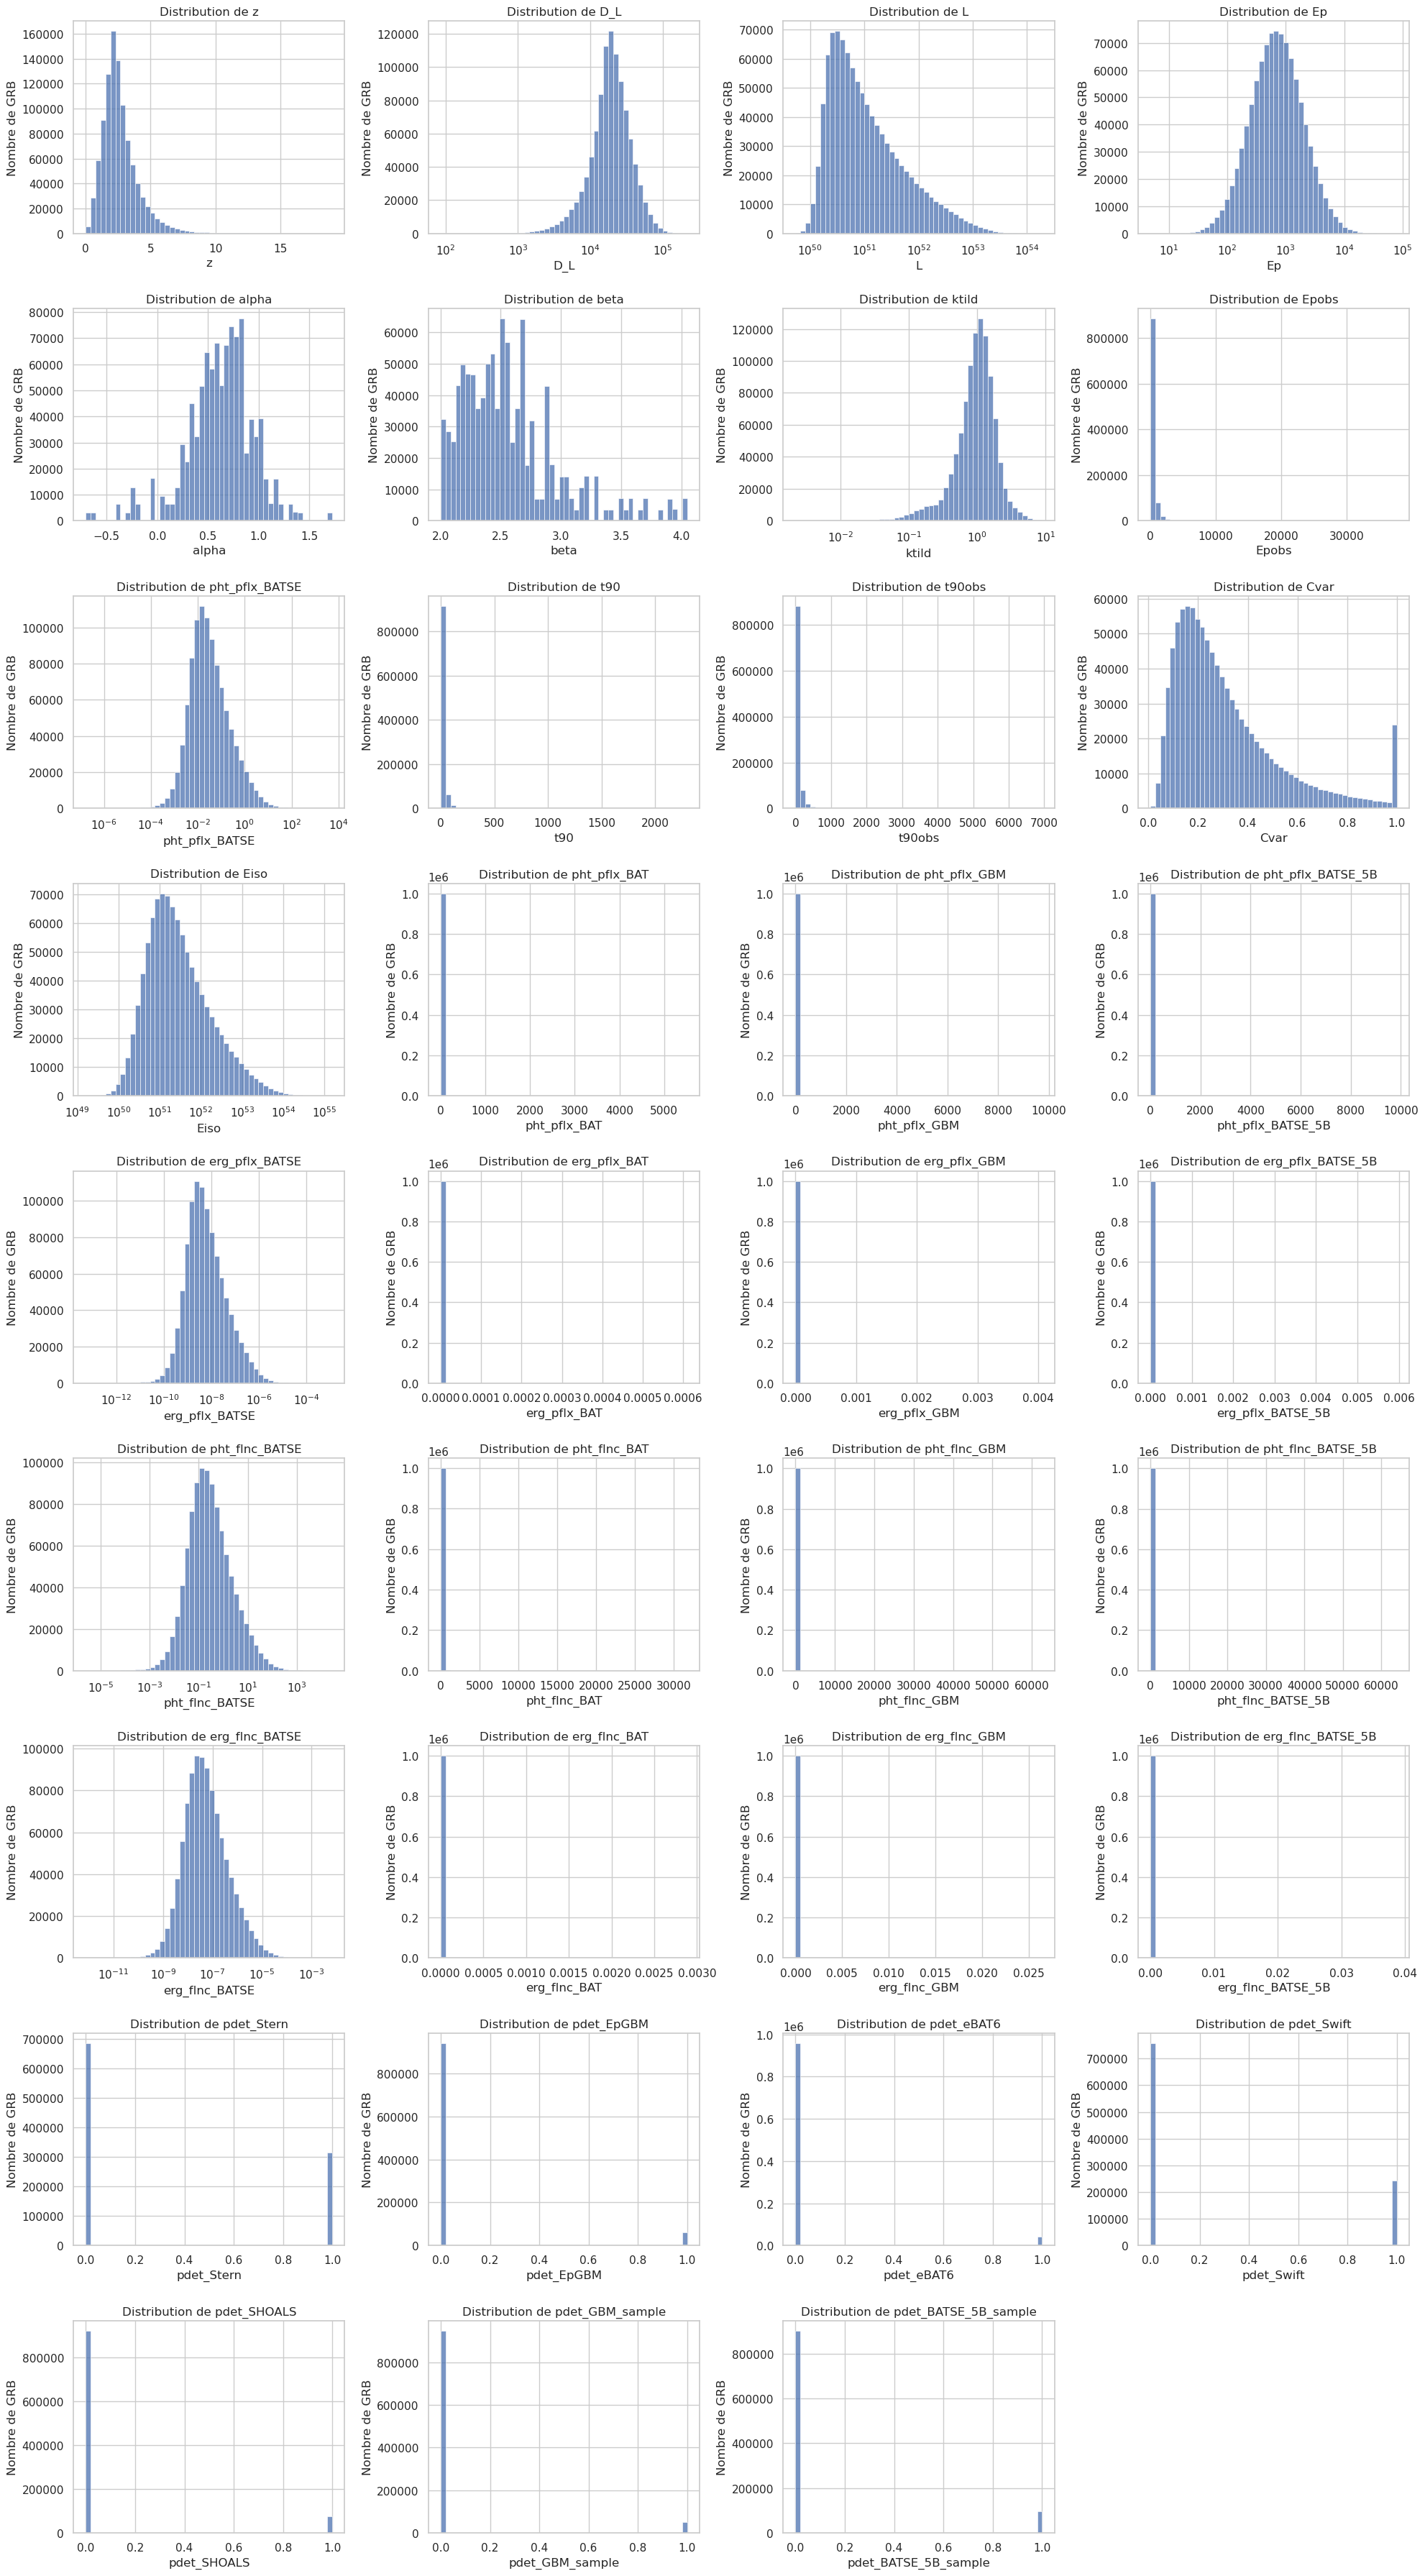

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configure le style de seaborn pour des graphiques plus jolis
sns.set_theme(style="whitegrid")

# Sélectionne uniquement les colonnes numériques pour les histogrammes
numeric_cols = df_properties.select_dtypes(include=np.number).columns.tolist()

# Calcule la disposition de la grille de graphiques
n_cols = 4
# Utilise np.ceil au lieu de math.ceil
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# Crée la figure et les sous-graphiques
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
# Aplatit la grille pour une itération facile (gère le cas d'une seule ligne)
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]


# Liste des colonnes à afficher avec une échelle de données logarithmique
log_scale_cols = ['L', 'Ep', 'D_L', 'Eiso', 'pht_pflx_BATSE', 'erg_pflx_BATSE', 'pht_flnc_BATSE', 'erg_flnc_BATSE', 'ktild']

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Détermine si l'axe des x doit être en échelle log
    log_x = col in log_scale_cols and df_properties[col].min() > 0
    
    # Crée l'histogramme avec seaborn
    sns.histplot(data=df_properties, x=col, ax=ax, log_scale=log_x, bins=50)
    
    ax.set_title(f'Distribution de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre de GRB')

# Masque les sous-graphiques inutilisés
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

# Améliore la disposition pour éviter que les titres et les étiquettes se chevauchent
plt.tight_layout()
plt.show()

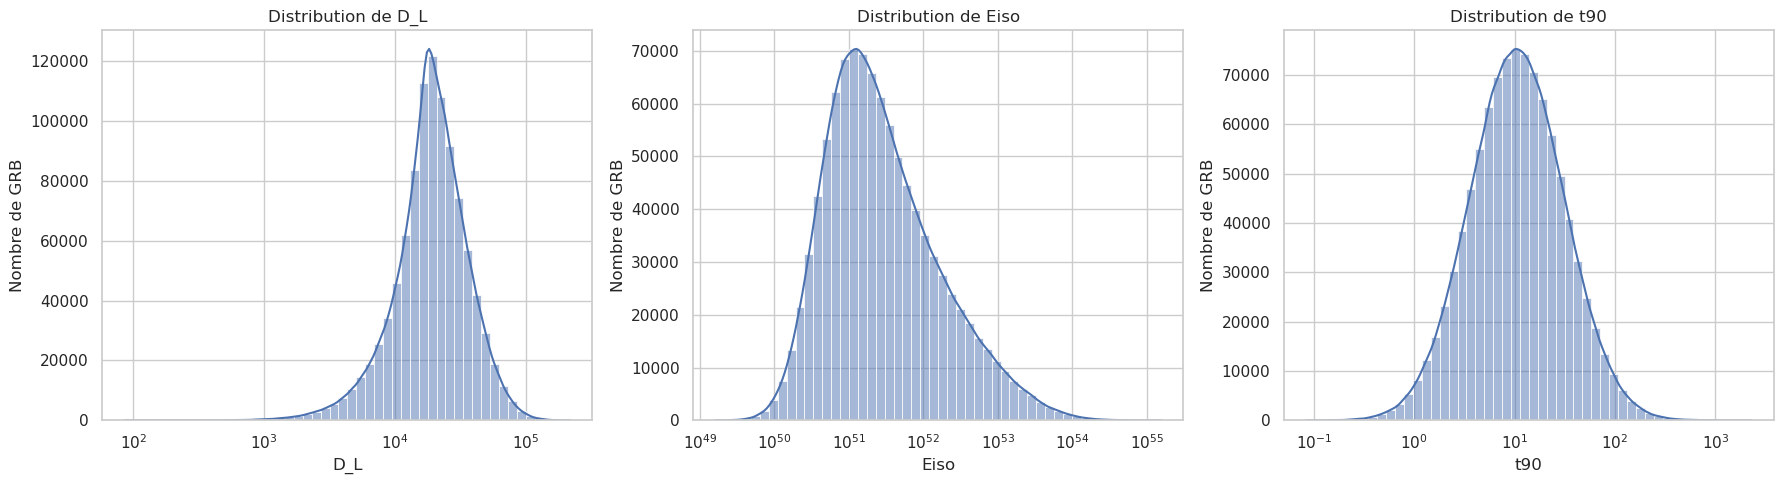

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configure le style de seaborn pour des graphiques plus jolis
sns.set_theme(style="whitegrid")

# Liste des colonnes spécifiques à afficher
cols_to_plot = ['D_L', 'Eiso', 't90']

# Crée une figure avec une ligne de 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Liste des colonnes à afficher avec une échelle de données logarithmique
log_scale_cols = ['D_L', 'Eiso', 't90']

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # Vérifie si la colonne existe dans le DataFrame
    if col in df_properties.columns:
        # Détermine si l'axe des x doit être en échelle log
        log_x = col in log_scale_cols and df_properties[col].min() > 0
        
        # Crée l'histogramme avec la courbe KDE superposée
        sns.histplot(data=df_properties, x=col, ax=ax, log_scale=log_x, bins=50, kde=True)
        
        ax.set_title(f'Distribution de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Nombre de GRB')
    else:
        ax.set_title(f'Colonne "{col}" non trouvée')
        ax.text(0.5, 0.5, 'Non disponible', ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])

# Améliore la disposition
plt.tight_layout()
plt.show()

Statistiques descriptives pour les colonnes sélectionnées :
                  D_L          Eiso             t90
count  1000000.000000  1.000000e+06  1000000.000000
mean     22677.815235  2.072383e+52       18.867091
std      14728.498033  1.087017e+53       28.068150
min         85.786899  1.610532e+49        0.083588
25%      13318.637049  7.992183e+50        5.071523
50%      19291.420624  2.176234e+51       10.494259
75%      28136.816482  8.223400e+51       21.789702
max     218355.240268  1.556915e+55     2298.546381




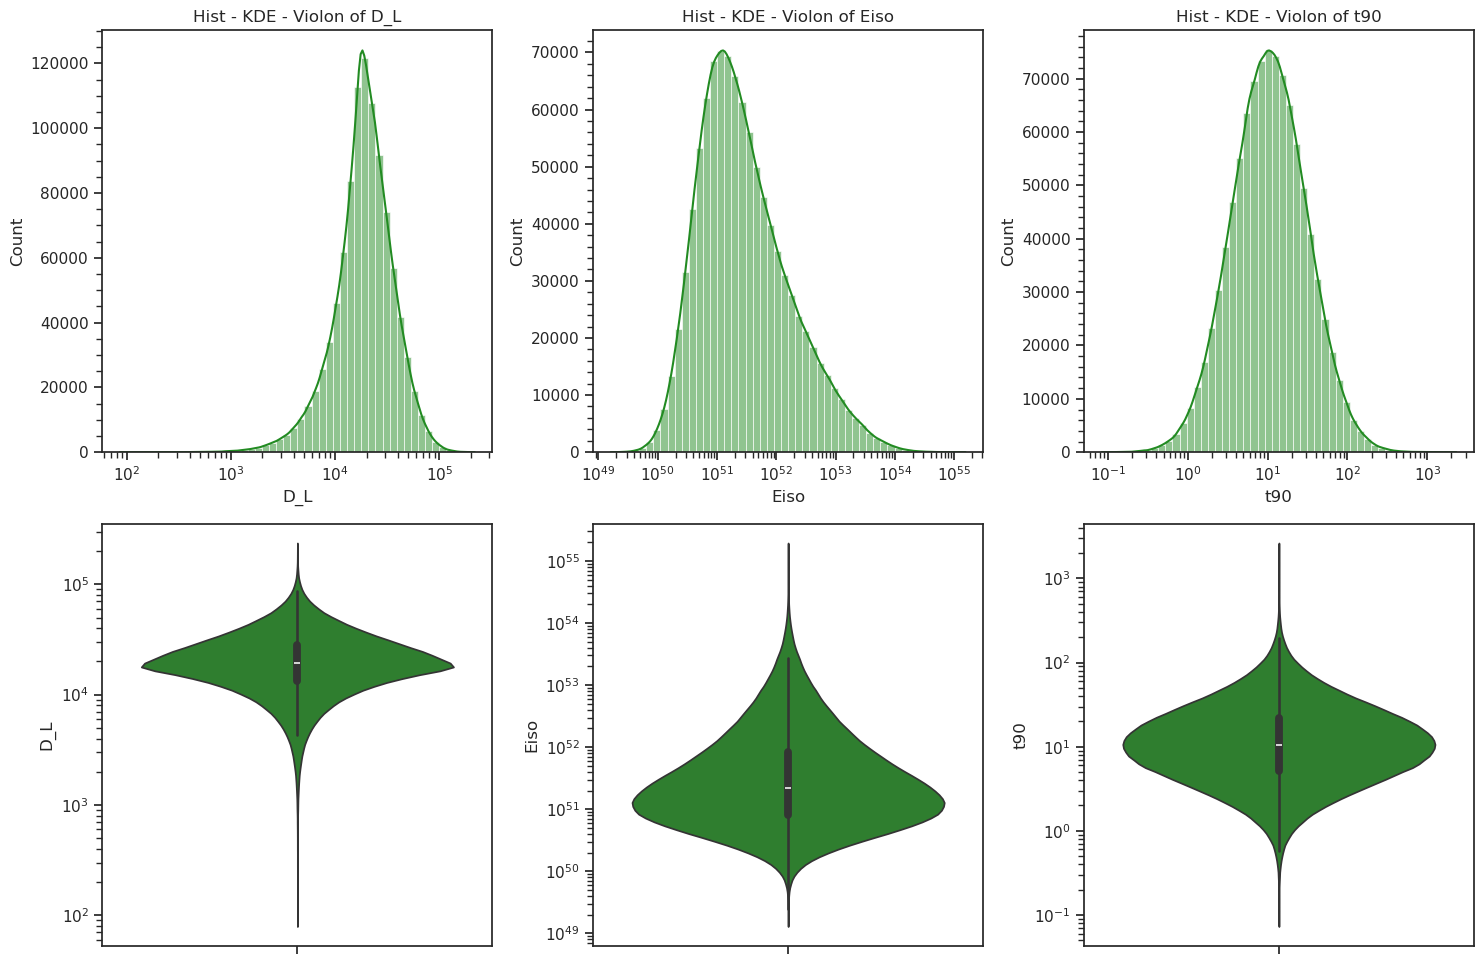

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Calcul des statistiques descriptives ---
print("Statistiques descriptives pour les colonnes sélectionnées :")
stats = df_properties[['D_L', 'Eiso', 't90']].describe()
print(stats)
print("\n" + "="*50 + "\n")

# Configure le style
sns.set_theme(style="ticks")

# Crée une figure pour plusieurs graphiques
# Nous allons faire une ligne pour chaque type de graphique
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols_to_plot = ['D_L', 'Eiso', 't90']
log_scale_cols = ['D_L', 'Eiso', 't90']

for i, col in enumerate(cols_to_plot):
    ax = axes[0, i]
    log_x = col in log_scale_cols and df_properties[col].min() > 0
    sns.histplot(data=df_properties, x=col, ax=ax, log_scale=log_x, bins=50, kde=True, color='forestgreen')
    ax.set_title(f'Hist - KDE - Violon of {col}')


for i, col in enumerate(cols_to_plot):
    ax = axes[1, i]
    log_y = col in log_scale_cols and df_properties[col].min() > 0
    sns.violinplot(data=df_properties, y=col, ax=ax, log_scale=log_y, color='forestgreen')



plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [ ]:
import numpy as np
import joblib
from sklearn.neighbors import KernelDensity

# --- 1. Définition des colonnes et préparation ---
cols_for_kde = ['D_L', 'Eiso', 't90']
kde_models = {}

print("Création des modèles KDE pour chaque paramètre...\n")

for col in cols_for_kde:
    print(f"--- Traitement de : {col} ---")
    
    # --- a. Préparation des données ---
    # Sélectionne la colonne, filtre les valeurs non-positives et passe en log10
    data = df_properties[col].copy()
    data = data[data > 0]
    log_data = np.log10(data)
    
    # Reshape les données pour scikit-learn (doit être un tableau 2D)
    log_data_reshaped = log_data.values.reshape(-1, 1)
    
    print(f"Nombre de points de données utilisés : {len(log_data_reshaped)}")
    
    # --- b. Création et ajustement du modèle KDE ---
    # 'scott' est une bonne estimation de départ pour la largeur de bande (bandwidth)
    kde = KernelDensity(kernel='gaussian', bandwidth='scott')
    kde.fit(log_data_reshaped)
    
    print("Modèle KDE ajusté.")
    
    # --- c. Sauvegarde du modèle ---
    filename = f'kde_{col}.joblib'
    joblib.dump(kde, filename)
    
    print(f"Modèle sauvegardé sous le nom : {filename}\n")
    
    # Stocke le modèle pour l'exemple d'utilisation
    kde_models[col] = kde

# --- 2. Exemple de chargement et d'utilisation ---
print("\n--- Exemple d'utilisation ---")

# Valeurs de test (non-log)
test_value_dl = 1000
test_value_eiso = 1e52
test_value_t90 = 20

# On doit passer les valeurs en log10 et les reshap-er
log_test_dl = np.log10(test_value_dl).reshape(1, -1)
log_test_eiso = np.log10(test_value_eiso).reshape(1, -1)
log_test_t90 = np.log10(test_value_t90).reshape(1, -1)

# Évaluation de la log-vraisemblance pour chaque paramètre
log_lik_dl = kde_models['D_L'].score_samples(log_test_dl)
log_lik_eiso = kde_models['Eiso'].score_samples(log_test_eiso)
log_lik_t90 = kde_models['t90'].score_samples(log_test_t90)

print(f"Log-vraisemblance pour D_L = {test_value_dl}: {log_lik_dl[0]}")
print(f"Log-vraisemblance pour Eiso = {test_value_eiso}: {log_lik_eiso[0]}")
print(f"Log-vraisemblance pour t90 = {test_value_t90}: {log_lik_t90[0]}")

# Si vous supposez que les paramètres sont indépendants, 
# la log-vraisemblance jointe est la somme des log-vraisemblances individuelles.
joint_log_likelihood = log_lik_dl[0] + log_lik_eiso[0] + log_lik_t90[0]
print(f"\nLog-vraisemblance jointe (supposant l'indépendance) : {joint_log_likelihood}")

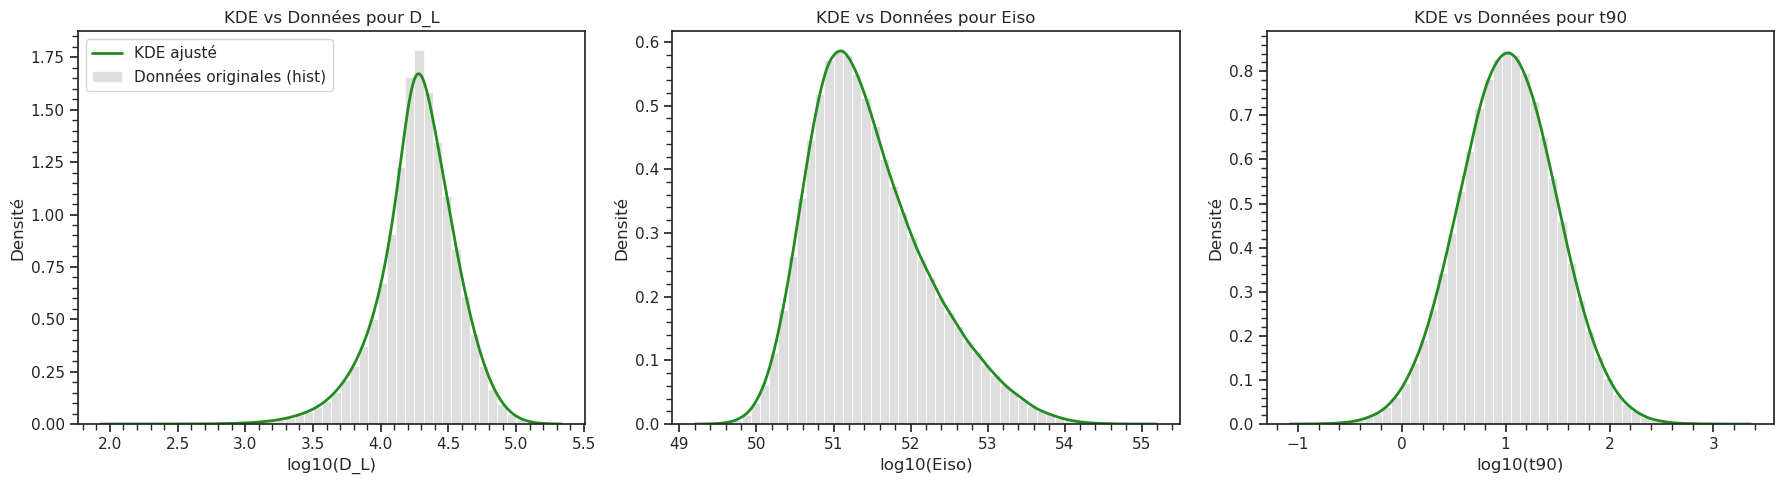

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Configuration des graphiques ---
cols_to_plot = ['D_L', 'Eiso', 't90']
fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(18, 5))

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # --- a. Récupération des données et du modèle ---
    kde = kde_models[col]
    
    # Données originales (en log) pour l'histogramme
    data = df_properties[col].copy()
    data = data[data > 0]
    log_data = np.log10(data)
    
    # --- b. Création de l'axe X pour la courbe KDE ---
    # On génère 1000 points entre le min et le max des données pour une courbe lisse
    x_grid = np.linspace(log_data.min(), log_data.max(), 1000)
    
    # --- c. Évaluation du KDE sur la grille ---
    # On utilise score_samples qui renvoie la log-densité, puis on passe à l'exponentielle
    log_density = kde.score_samples(x_grid.reshape(-1, 1))
    density = np.exp(log_density)
    
    # --- d. Tracé de l'histogramme des données réelles ---
    # 'stat="density"' normalise l'histogramme pour que l'aire sous la courbe soit 1
    sns.histplot(log_data, bins=50, stat="density", ax=ax, 
                 label='Données originales (hist)', color='lightgray')
    
    # --- e. Tracé de la courbe KDE ---
    ax.plot(x_grid, density, color='forestgreen', lw=2, label='KDE ajusté')
    
    # --- g. Mise en forme ---
    ax.set_title(f'KDE vs Données pour {col}')
    ax.set_xlabel(f'log10({col})')
    ax.set_ylabel('Densité')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


Graphique de densité jointe pour Eiso et t90 :


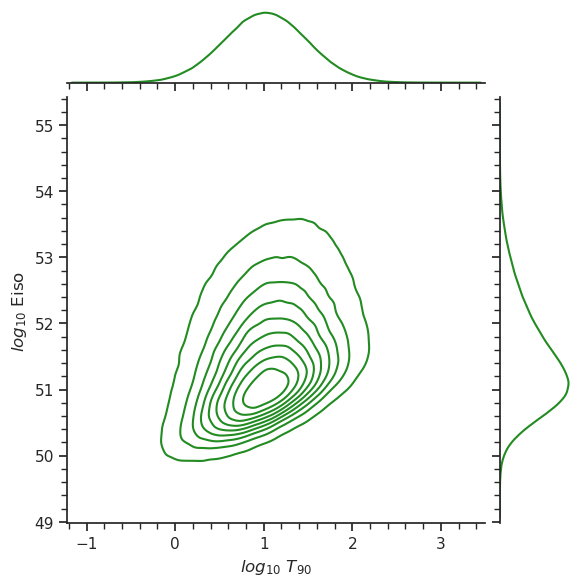

In [27]:
# --- Graphique bonus: Jointplot pour voir la corrélation ---
print("\nGraphique de densité jointe pour Eiso et t90 :")
sns.set_theme(style="ticks")
# Crée une copie temporaire du DataFrame pour les logs
plot_data = df_properties[['t90', 'Eiso']].copy()

# Convertit les données en log10. On filtre les valeurs non positives pour éviter les erreurs.
plot_data['log_t90'] = np.log10(plot_data['t90'][plot_data['t90'] > 0])
plot_data['log_Eiso'] = np.log10(plot_data['Eiso'][plot_data['Eiso'] > 0])

# Crée le jointplot sur les données en log
g = sns.jointplot(
    data=plot_data.dropna(),
    x='log_t90', 
    y='log_Eiso', 
    kind='kde', 
    fill=False,
    color= 'forestgreen'
)
# Met à jour les labels pour refléter l'échelle logarithmique
g.set_axis_labels(r'$log_{10}$ $T_{90}$', r'$log_{10}$ Eiso')

plt.show()